In [42]:
%cd /home/soochul/umi_act/UMI_FT

/home/soochul/umi_act/UMI_FT


In [43]:
import os
import h5py
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
import plotly.graph_objects as go

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go
from scipy.spatial.transform import Rotation as R
import pickle
import zarr
from act.common.replay_buffer import ReplayBuffer
from omegaconf import OmegaConf
from act.codecs.imagecodecs_numcodecs import register_codecs
from act.common.pose_util import (
    pose_to_mat, mat_to_pose, 
    mat_to_pose10d, pose10d_to_mat)
from act.common.pose_repr_util import convert_pose_mat_rep

In [45]:
OmegaConf.register_new_resolver("eval", eval, replace=True)
register_codecs()

In [54]:
zarr_path = '/home/soochul/GoPro_20250519/dataset_depth.zarr.zip'
zip_store = zarr.ZipStore(zarr_path, mode='a')
root = zarr.group(zip_store)
replay_buffer = ReplayBuffer.create_from_group(root)
num_episodes = len(replay_buffer.episode_ends)
print(f"Loaded replay buffer with {num_episodes} episodes.")
episode_idx = np.random.choice(num_episodes)
print(f"Replaying episode {episode_idx}...")
ep = replay_buffer.get_episode(episode_idx)
# print(ep.keys()) 
# dict_keys(['camera0_rgb', 'robot0_demo_end_pose', 'robot0_demo_start_pose', 
# 'robot0_eef_pos', 'robot0_eef_rot_axis_angle', 
# 'robot0_force', 'robot0_gripper_width', 'robot0_torque'])
for robot_idx in range(1):
    pos_replay = ep[f'robot{robot_idx}_eef_pos'][:]
    rot_replay = ep[f'robot{robot_idx}_eef_rot_axis_angle'][:]
    grip_replay = ep[f'robot{robot_idx}_gripper_width'][:]
actions = np.concatenate([pos_replay, rot_replay, grip_replay], axis=-1)

Loaded replay buffer with 203 episodes.
Replaying episode 76...


In [55]:
hdf5_path = '/home/soochul/GoPro_20250519_hdf5/'
num_episodes = 202
print(episode_idx)
dataset_path = os.path.join(hdf5_path, f'ep_{episode_idx}.hdf5')

76


In [56]:
with h5py.File(dataset_path, 'r') as root:
    is_sim = root.attrs['sim']
    original_action_shape = root['/action'].shape
    episode_len = original_action_shape[0]
    # print(root['/action'][:].shape) # ndarray # max_ep_length, action dim (1885, 10)
    
    for key in root['/observations'].keys():
        # ['eef_pos', 'eef_rot', 'eef_rot_start', 'force', 'gripper_width', 'images', 'torque']
        print(key)
        if key == 'images':
            # images is a Group -> cam_name -> [:] -> ndarray
            print(root[f'/observations/{key}/top'][:].shape)
            # images: max_ep_length, channel, H, W
        elif key == 'depth_images':
            print(root[f'/observations/{key}/top'][:].shape)
        else:
            # others are Dataset -> [:] -> ndarray
            print(root[f'/observations/{key}'][:].shape)
            # pos : max_ep_length, 3
            # rot : max_ep_length, 6
            # rot_start : max_ep_length, 6
            # force : max_ep_length, 3
            # torque: max_ep_length, 3
            # gripper_width : max_ep_length, 1


depth_images
(836, 3, 224, 224)
eef_pos
(836, 3)
eef_rot
(836, 6)
eef_rot_start
(836, 6)
force
(836, 3)
gripper_width
(836, 1)
images
(836, 3, 224, 224)
torque
(836, 3)


In [57]:
def plot_traj(pos):
    # Extract relevant data
    x = pos[: , 0]
    y = pos[: , 1]
    z = pos[: , 2]

    ep_length = pos.shape[0]
    timestamps = np.array(range(ep_length))
    color_intensity_time = timestamps / timestamps[-1]
    
    # Create the 3D plot
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    sc = ax.scatter(x, y, z, c=color_intensity_time, cmap='cool', s=1)
    
    # Label axes
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    
    # Add color bar for reference
    
    plt.show()

def plot_width(width):
    ep_length = width.shape[0]
    timestamps = np.array(range(ep_length))

    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1)
    x = timestamps
    y = width
    ax.plot(x, y)
    plt.show()

def plotly_pos(tcp_points):
    order = list(range(len(tcp_points)))
    fig = go.Figure(data=[go.Scatter3d(
    x=tcp_points[:, 0],
    y=tcp_points[:, 1],
    z=tcp_points[:, 2],
    mode='lines+markers',
    marker=dict(
        size=5,
        color=order,      # Color markers according to order
        colorscale='Viridis',
        colorbar=dict(title='Order')
    ),
    line=dict(
        width=4,
        color='blue'
    )
    )])
    
    fig.update_layout(
        title='Interactive TCP Trajectory',
        scene=dict(
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z'
        )
    )
    fig.show()


In [72]:
def make_relative_pose(pos, rot):
    '''
        pos: ep_len, 3
        rot: ep_len, 3
    '''
    pose_mat = pose_to_mat(np.concatenate([pos, rot], axis = -1)) 
    # start_pose = np.concatenate([pos[0], rot[0]], axis = -1)
    # start_pose_mat = pose_to_mat(start_pose)
    rel_obs_pose_mat = convert_pose_mat_rep(
                pose_mat,
                # base_pose_mat=start_pose_mat,
                base_pose_mat=pose_mat[-1],
                pose_rep='relative',
                backward=False)
    rel_obs_pose = mat_to_pose10d(rel_obs_pose_mat)
    rel_pos = rel_obs_pose[:, :3]
    rel_rot = rel_obs_pose[:, 3:]
    return rel_pos

In [73]:
rel_pos = make_relative_pose(pos_replay, rot_replay)

In [80]:
dataset_path = os.path.join(hdf5_path, f'ep_{episode_idx}.hdf5')
pos = None
width = None
images = None
depth_images = None
with h5py.File(dataset_path, 'r') as root:
    act_pos = root['/observations/eef_pos'][:]
    width = root['/observations/gripper_width'][:]
    images = root[f'/observations/images/top'][:]
    depth_images = root[f'/observations/depth_images/top'][:]

(3, 224, 224)
(224, 224, 3)
251
0


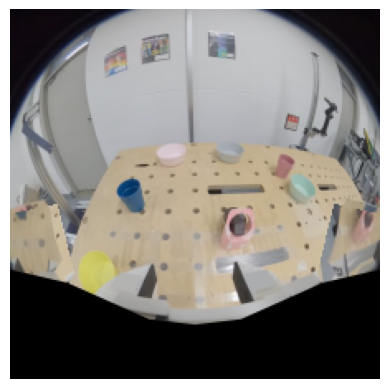

In [75]:
image = images[500]
print(image.shape)
image = np.moveaxis(image, 0, -1)
print(image.shape)
print(image.max())
print(image.min())
plt.imshow(image)
plt.axis("off") 
plt.show()

(224, 224, 3)
(224, 224, 3)
255
0


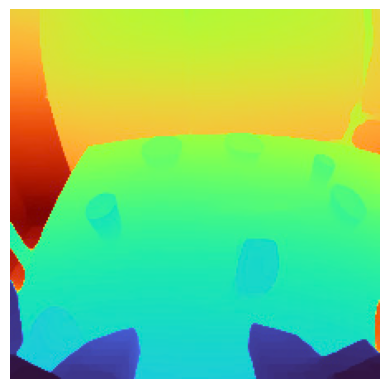

In [76]:
depth_image = depth_images[500]
print(image.shape)
depth_image = np.moveaxis(depth_image, 0, -1)
print(depth_image.shape)
print(depth_image.max())
print(depth_image.min())
plt.imshow(depth_image)
plt.axis("off") 
plt.show()

In [77]:
plotly_pos(pos_replay)

In [78]:
plotly_pos(rel_pos)

In [81]:
plotly_pos(act_pos)

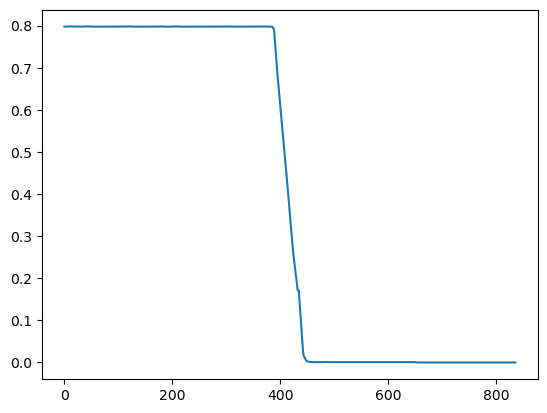

In [82]:
plot_width(width)